<div style="
    background: linear-gradient(135deg, #e8f4ff, #f4eaff);
    border-left: 7px solid #5271ff;
    padding: 28px;
    border-radius: 14px;
    text-align: center;
">

# 🚗 Monthly Car Sales Forecasting

## Time Series Forecasting using SARIMA

### 📊 Predicting Future Monthly Car Sales

**Prepared by:** Princy Jaat   
**Dataset:** California Housing Dataset from Scikit-learn.

</div>

# Decision Tree Regressor

## Problem Statement

In this notebook, we will implement the Decision Tree Regressor algorithm using Python.

Decision Tree Regressor is used to predict continuous numerical values.  
It works by splitting the dataset into smaller parts based on feature conditions.

## Dataset Used

We will use the California Housing Dataset from Scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Loading

Now we will load the California Housing dataset and convert it into a Pandas DataFrame.

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["target"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis (EDA)

In this step, we will check:

- Dataset shape
- Missing values
- Data types
- Statistical summary
- Correlation analysis
- Visualization

In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (20640, 9)

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
target,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


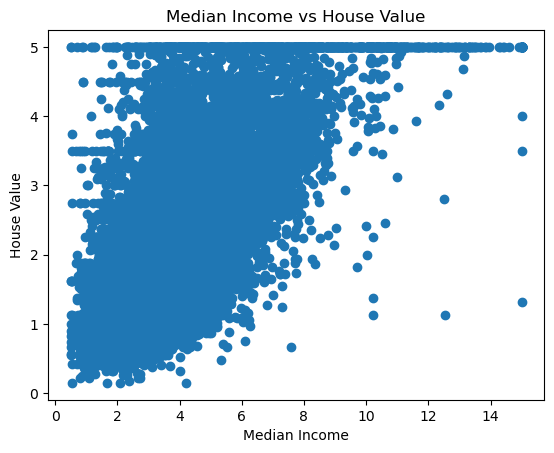

In [5]:
plt.scatter(df["MedInc"], df["target"])
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Median Income vs House Value")
plt.show()

## Data Preprocessing

In this dataset:

- There are no missing values
- All features are numerical
- Target column is continuous

Now we will separate input features and target column.

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


## Model Building

Now we will create the Decision Tree Regressor model.

We use max_depth to control the depth of the tree and reduce overfitting.

In [8]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)

## Model Training

Now we will train the Decision Tree Regressor model using training data.

In [9]:
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Model Prediction

Now we will predict house values using testing data.

In [10]:
y_pred = dt_model.predict(X_test)

y_pred[:10]

array([1.16857267, 1.27158128, 3.19958174, 2.20476301, 1.64279735,
       2.33790011, 1.92062128, 1.64279735, 2.37549582, 4.77878874])

## Model Evaluation

We will evaluate the model using:

- MAE
- MSE
- RMSE
- R² Score

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.5222592972077786
MSE: 0.5245146178314735
RMSE: 0.7242338143386247
R2 Score: 0.5997321244428706


## Result Interpretation

Decision Tree Regressor predicts values by creating decision rules from the dataset.

A lower RMSE means the model has fewer prediction errors.  
A higher R² score means the model explains the target values better.

In [12]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
20046,0.47700,1.168573
3024,0.45800,1.271581
15663,5.00001,3.199582
20484,2.18600,2.204763
9814,2.78000,1.642797
13311,1.58700,2.337900
7113,1.98200,1.920621
7668,1.57500,1.642797
18246,3.40000,2.375496
5723,4.46600,4.778789


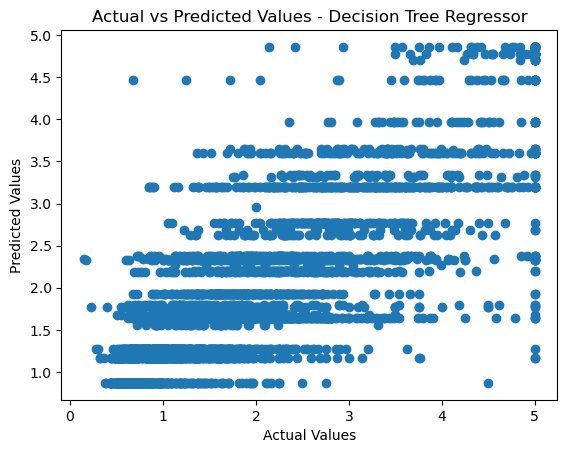

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Decision Tree Regressor")
plt.show()

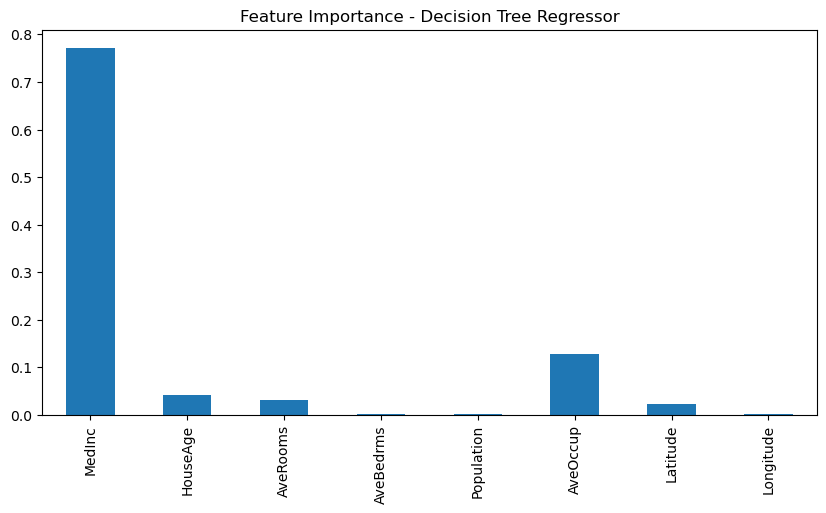

In [14]:
importance = pd.Series(dt_model.feature_importances_, index=X.columns)

importance.plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance - Decision Tree Regressor")
plt.show()

<div style="
    background: linear-gradient(135deg, #effaf3, #edf4ff);
    border-left: 7px solid #2e9d62;
    padding: 24px;
    border-radius: 12px;
">

## ✅Conclusion

In this notebook, we successfully implemented Decision Tree Regressor using Python.

### Steps completed

- Dataset loading
- Exploratory Data Analysis
- Data preprocessing
- Train-test split
- Model building
- Model training
- Model prediction
- Model evaluation
- Result interpretation

Decision Tree Regressor is useful for predicting continuous values such as house prices, sales, or temperature.